In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [24]:
titanic = sns.load_dataset("titanic")

features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

# handle missing data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# encode
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state=42
)

In [25]:
# Decision Tree
model = DecisionTreeClassifier(max_depth=4)         # first try without defining max_depth 

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training accuracy: ", accuracy_score(y_train, y_pred_train)*100, "%")
print("Testing accuracy: ", accuracy_score(y_test, y_pred_test)*100, "%")
# classic case of overfitting

Training accuracy:  84.75120385232745 %
Testing accuracy:  82.46268656716418 %


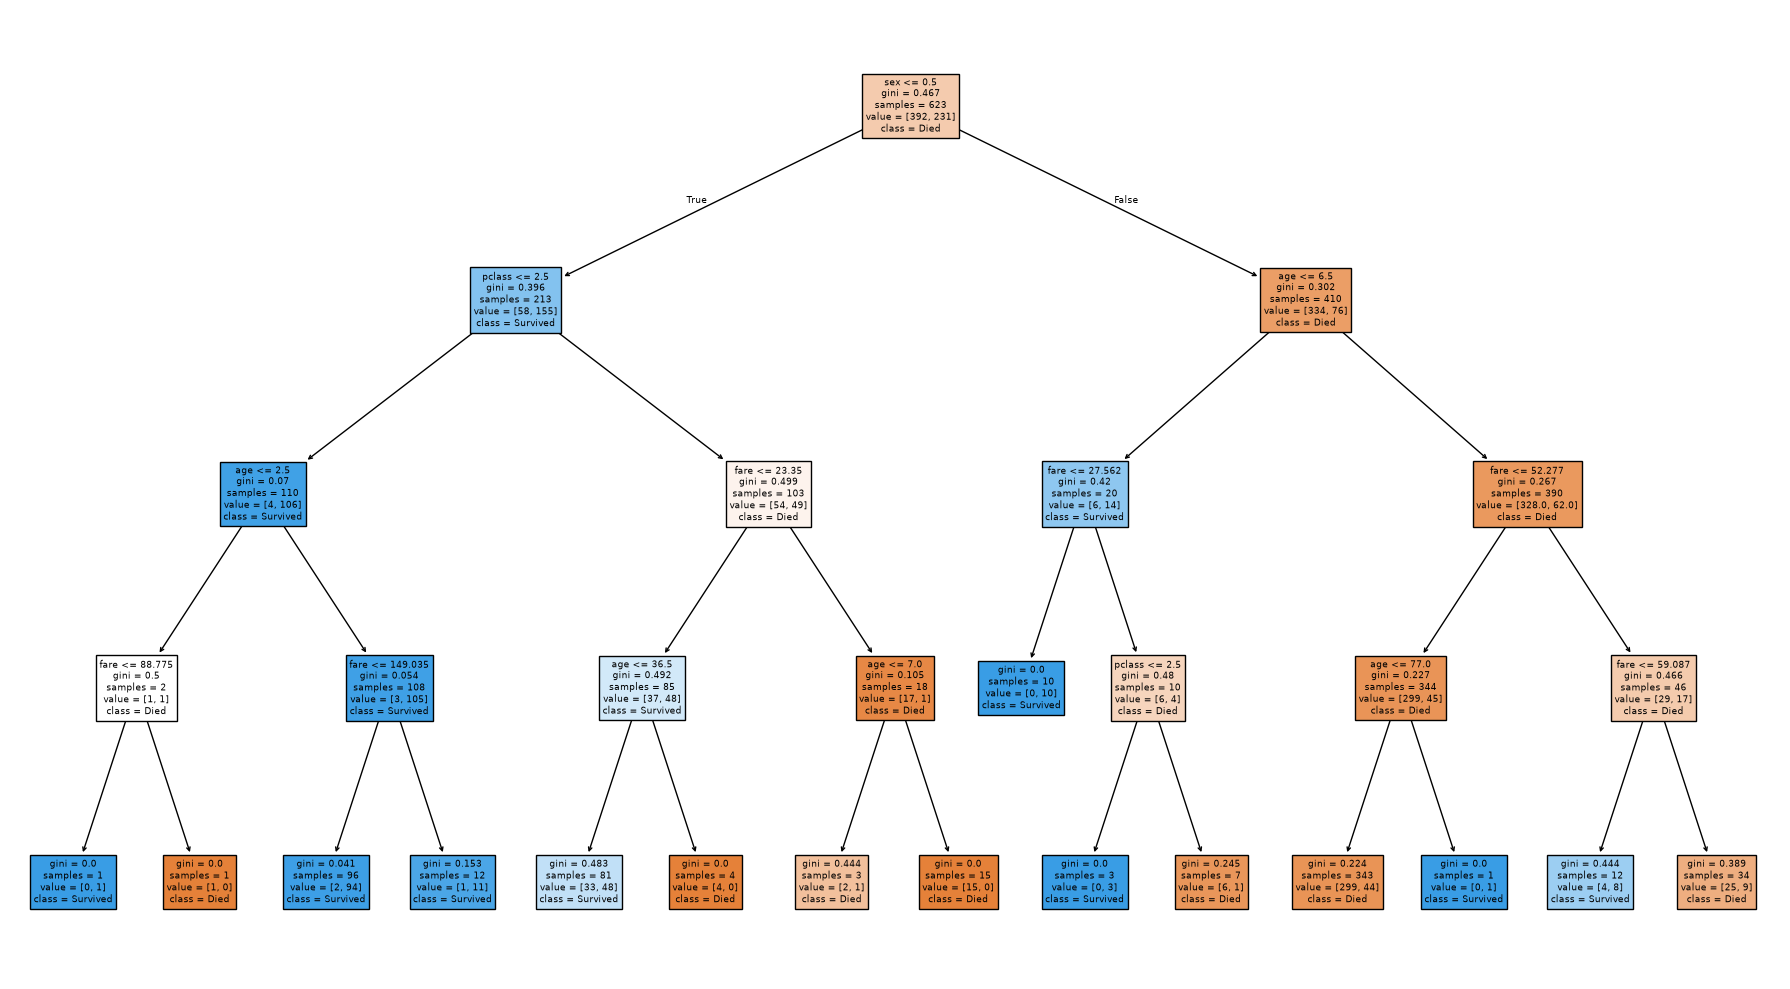

In [26]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)

plt.tight_layout()

In [27]:
# Random forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=501,
    oob_score=True,
    max_depth = 4
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"OOB score: { rf.oob_score_ * 100} %")
print(f"Testing accuracy: {accuracy_score(y_test, y_pred)* 100} %")

OOB score: 82.02247191011236 %
Testing accuracy: 81.34328358208955 %


In [28]:
# Bagging classifier

from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)
bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("Accuracy_score: ", accuracy_score(y_test, y_pred)* 100)

Accuracy_score:  76.86567164179104


In [29]:
# Bagging using logistic regression
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)
bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)
print("Accuracy_score: ", accuracy_score(y_test, y_pred)* 100)

Accuracy_score:  79.47761194029852
